In [1]:
import math as m
import numpy as np  # 1.7 or higher

import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

from ipywidgets import interactive
from IPython.display import display, Image
from IPython.display import YouTubeVideo

%precision %.4f # this doesn't actually seem to work
np.set_printoptions(suppress=True, 
                    formatter={'float_kind':'{:14.4f}'.format})  
%matplotlib inline


import PIL
from io import BytesIO


import cv2


import qgrid
import pandas as pd

import sympy as sym
sym.init_printing(order="none")
from sympy.vector import CoordSys3D
import sympy.vector as symvec

import scipy
import scipy.constants
sic = scipy.constants
import scipy.signal as signal
import control
import control.matlab



import linear as lin
import quat
import slerp




def display_img_array(ima):
    im = PIL.Image.fromarray(ima)
    bio = BytesIO()
    im.save(bio, format='png')
    display(Image(bio.getvalue(), format='png'))

def display_image(path):
    pil_im = PIL.Image.open(path)
    display(pil_im)



# embed python variables in latex
# then render with md
lx = lambda c: "$" + sym.latex(c) + "$"



Numpy detected


In [2]:
class TableGrapher(object):
    ds = u'\N{DEGREE SIGN}'
    ptoo = u'\N{PROPORTIONAL TO}'
    def __init__(self, 
                 filename=None, 
                 dataframe=None, 
                 figsize=(14,10), 
                 title="Table Graph",
                 grid=True,
                 axhline=True,
                 xalabel="Time(s)",
                 aoi_slice = None
                ):
        if not (dataframe is None):
            self.df = dataframe
        elif not (filename is None):
            self.df = pd.read_csv(filename)
        else:
            self.df = None
        
        if aoi_slice == None:
            aoi_slice = slice(0, len(self.df))
        self.df = self.df[aoi_slice]
        
        self.asnum = lambda k: self.df[k].to_numpy()
        
        dftime = self.asnum('time')
        dftime = dftime - dftime[0]
        self.df['time'] = dftime
        self.time = dftime
        
        self.figsize = figsize
        self.fig, self.axis = plt.subplots(figsize=figsize)
        
        self.title = title
        self.grid = grid
        self.axhline = axhline
        self.xalabel = xalabel
    def draw(self):
        pass
    def plot(self):
        display(qgrid.show_grid(self.df, 
                grid_options={'forceFitColumns': False, 'defaultColumnWidth': 100},
                show_toolbar=True)) # display database as spreadsheet
        self.draw()
        self.axis.set_title(self.title)
        self.axis.set_xlabel(self.xalabel)
        if self.axhline:
            self.axis.axhline(0,color='black')
        if self.grid:
            self.axis.grid()
        self.axis.legend()
        #display(self.axis)
        return None

In [3]:
def rscale(a_, b_, c_, d_, k_):
    "This function will find the scale factor for a full-state feedback system to eliminate the steady-state error."
    # https://www.ee.usyd.edu.au/tutorials_online/matlab/extras/rscale.html
    # http://octave-online.net
    # https://docs.scipy.org/doc/numpy-dev/user/numpy-for-matlab-users.html
    s = a_.shape[0]
    print("s:", s)
    z = np.concatenate((np.zeros((1, s))[0], [1]), axis=0)
    print("z:", z)
    top = np.concatenate((a_, b_), axis=1)
    bot = np.concatenate((c_, d_), axis=0)
    tot = np.vstack((top, bot))
    print("tot:", tot)
    N = np.linalg.inv(tot).dot(z)
    print("N: ", N)
    Nx = N[0:s]
    print("Nx", Nx)
    Nu = N[s]
    print("Nu:", Nu)
    Nbar = Nu + k_.dot(Nx)
    print("Nbar", Nbar)
    return Nbar[0]

In [4]:
# MACHINE FRAMES OF REFERENCE WRT CAMERA

# pitch down (right stick up+) commands machine roll right (plate angled down starboard)
# plate rotates cw on y axis, xz plane rotated by negative angle
# pitch up (right stick down-) commands machine roll left (plate angled down port)
# plate rotates ccw on y axis, xz plane rotated by positive angle

#mroll = -jpitch

# roll left (right stick left-) commands machine pitch down (plate angled down front)
# plate rotates ccw on x axis, yz plane rotated by postive angle
# roll right (right stick right+) commands machine pitch up (plate angled down back)
# plate rotates cw on x axis, yz plane rotated by negative angle

#mpitch = -jroll

# this should correspond to the machine angle being the js angle rotated +90 deg ccw on z
# the js angle is the machine angle rotated -90 deg cw on z

#m_point = rotate(z, 90, js_point)
#js_point = rotate(z, -90, m_point)

# this follows the code running on the machine, stuart.py line 394-ish

#pitch = -1*wirep.vals['roll']*disk_small
#roll = -1*wirep.vals['pitch']*disk_small

In [5]:
# damping ratio is ζ zeta

# cx = self.asnum('c3x') 
# cy = self.asnum('c3y')
# vx = self.asnum('v2x')
# vy = self.asnum('v2y')
# dt = self.asnum('dt2')

# dxo = {"t": T, 
#        "dist": xout.T[0]*1000, 
#        "vel": xout.T[1]*1000, 
#        "beam angle": np.degrees(xout.T[2]), 
#        "beam α": np.degrees(xout.T[3])}
# display(qgrid.show_grid(pd.DataFrame(dxo),

In [6]:
# two stages of kalman:
# observer on roll/pitch as an estimator
# predictor on x y vx vy, can we project forward one time step?
# probably use something like the below model for roll/pitch estimator
# then full state space model for ball physics for predictor



In [7]:
# https://www.bricklink.com/v2/catalog/catalogitem.page?P=41250#T=C
# Ball, Hard Plastic 52mm D, page has mass
ms = 13.9/1000 # ball mass: g->kg 
R = 26/1000 # ball radius: mm->m
# https://www.quora.com/What-is-the-volume-of-plastic-in-a-4x2-Lego-brick
ρ_ABS = 1070 # density of ABS plastic: 1070 kg/m^3
v_ABS = ms/ρ_ABS # volume of ABS in m^3
vsph = lambda r: (4/3)*m.pi*r**3
osm = vsph(R)*ρ_ABS
rvol = lambda M, ρ: ((3*M)/(4*m.pi*ρ))**(1/3)
Ris = rvol(osm-ms, ρ_ABS) # inner shell to subtracted
jsphsh = lambda r1, r2, m: (2/5)*m*( (r2**5 - r1**5) / (r2**3 - r1**3) )
J = jsphsh(Ris, R, ms)
g = -9.807 #m/s^2
H = -ms*g/(J/(R**2)+ms)

A = np.array([ 
    [0, 1, 0, 0],
    [0, 0, H, 0],
    [0, 0, 0, 1],
    [0, 0, 0, 0]
] )
B = np.array([[0], [0], [0], [1]])
C = np.array([1,  1,  1, 0])
D = np.array([0])
#ball_ss = signal.StateSpace(A, B, C, D, dt=50/1000)
ball_ss = signal.StateSpace(A, B, C, D)
#A, B, C, D, ball_ss
ball_ss

StateSpaceContinuous(
array([[0.00, 1.00, 0.00, 0.00],
       [0.00, 0.00, 6.03, 0.00],
       [0.00, 0.00, 0.00, 1.00],
       [0.00, 0.00, 0.00, 0.00]]),
array([[0],
       [0],
       [0],
       [1]]),
array([[1, 1, 1, 0]]),
array([[0]]),
dt: None
)

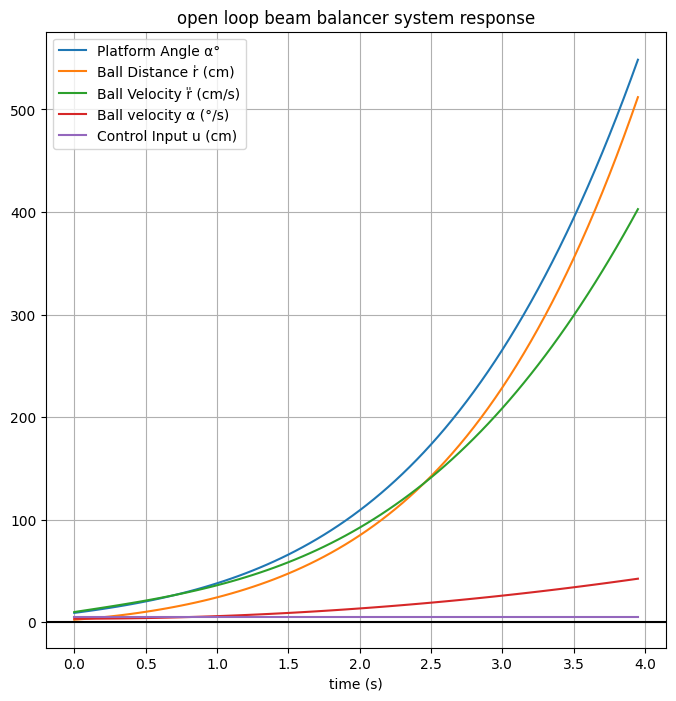

In [8]:
ds = u'\N{DEGREE SIGN}'
t = np.arange(0, 4, 50/1000) # 4 seconds, 50ms interval
#u = 0 * t
u = np.ones(len(t)) * (50/1000) 
x0 = np.array([25/1000, 100/1000, np.radians(2), 0]) # 25 mm, 100 mm/s, 2 degrees

dot = '\u030d'
dot2 = '\u030e'
rdot = 'r' + dot
rdot2 = 'r' + dot2


T, yout, xout =  signal.lsim(ball_ss, u, t, x0)
fig, axes = plt.subplots(figsize=(8,8), dpi=100)
#axes.plot(T, xout.transpose()[2], label = "xout")
axes.plot(T, np.degrees(yout), label = f"Platform Angle α{ds}")
axes.plot(T, xout.T[0]*100, label = f"Ball Distance {rdot} (cm)")
axes.plot(T, xout.T[1]*100, label = f"Ball Velocity {rdot2} (cm/s)")
axes.plot(T, xout.T[2]*100, label = f"Ball velocity α ({ds}/s)")

axes.plot(T, u*100, label = f"Control Input u (cm)")
axes.set_xlabel("time (s)")
axes.set_title("open loop beam balancer system response")
axes.axhline(0,color='black')
axes.grid()
axes.legend()
None

In [9]:
wD_eigvals_poles, vT_eigvecs = np.linalg.eig(A) # parames reversed from matlab
wD_eigvals_poles, vT_eigvecs

(array([0.00, 0.00, 0.00, 0.00]),
 array([[1.00, -1.00, 1.00, -1.00],
        [0.00, 0.00, -0.00, 0.00],
        [0.00, 0.00, 0.00, -0.00],
        [0.00, 0.00, 0.00, 0.00]]))

In [10]:
cbss = control.StateSpace(A, B, C, D)

In [11]:
cbtf = control.ss2tf(cbss)
cbtf

TransferFunction(array([-0.00, 1.00, 6.03, 6.03]), array([1.00, 0.00, 0.00, 0.00, 0.00]))

In [12]:
cbss.zeros(), cbss.poles()

(array([-4.76327605+0.j, -1.26572592+0.j]),
 array([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]))

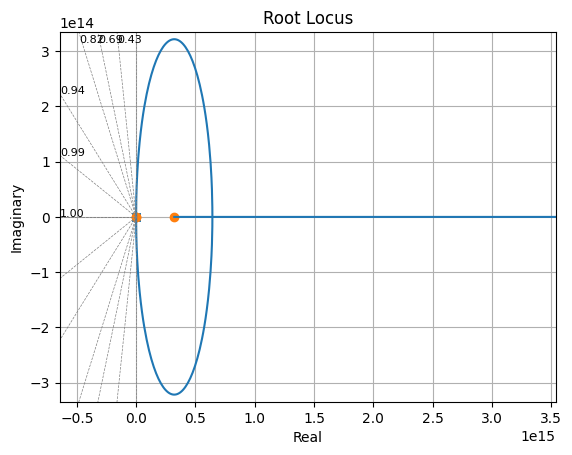

In [13]:
rlist, klist = control.rlocus(cbtf)#, kvect=np.linspace(100.0, -100.0, num=1000))
plt.grid()
#plt.legend()
plt.show()

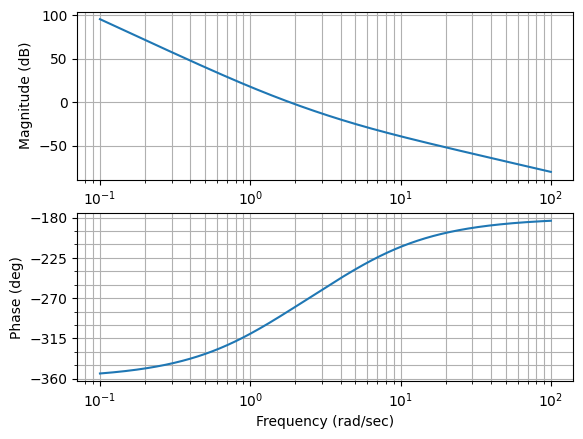

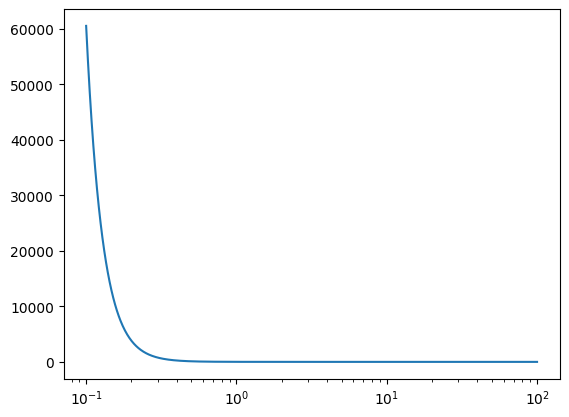

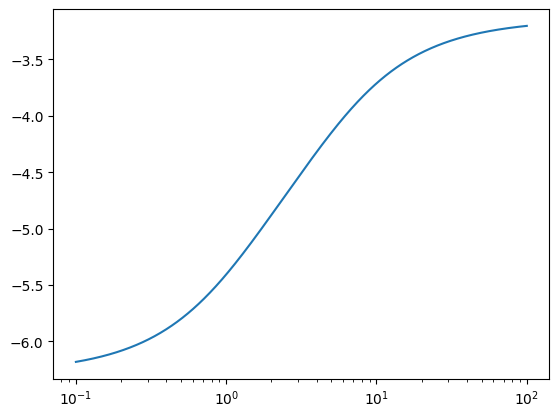

In [14]:
mag, phase, omega = control.matlab.bode(cbss)
#w, mag, phase
plt.figure()
plt.semilogx(omega, mag)    # Bode magnitude plot
plt.figure()
plt.semilogx(omega, phase)  # Bode phase plot
plt.show()

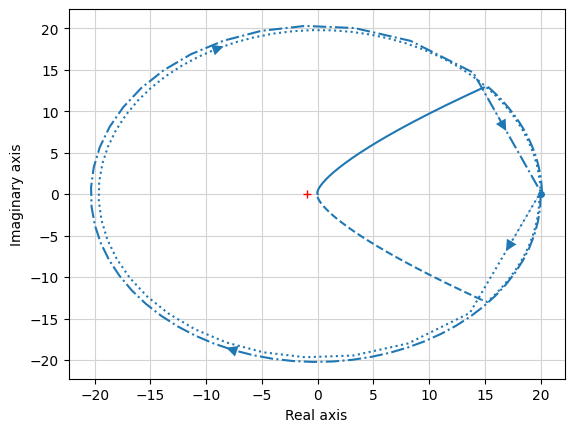

In [15]:
control.nyquist(cbss)

(array([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]),
 array([-4.76327605+0.j, -1.26572592+0.j]))

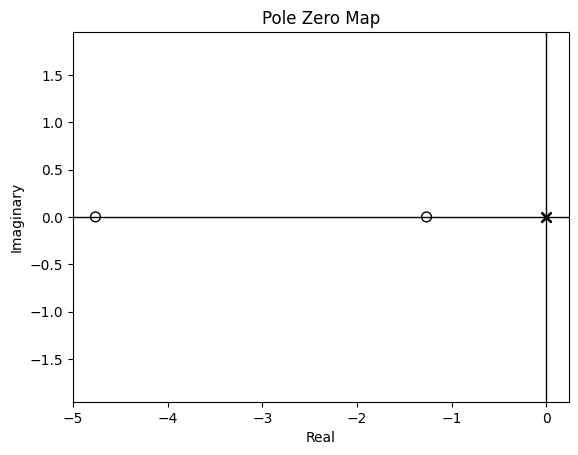

In [16]:
control.matlab.pzmap(cbss)

In [17]:
p1 = -2+2j
p2 = -2-2j
p3 = -20;
p4 = -80;

K = control.place(A, B, [p1, p2, p3, p4])
K

matrix([[2123.07, 1194.23, 2008.00, 104.00]])

In [18]:
sys_cl = signal.StateSpace(A-B*K, B, C, D)
sys_cl

StateSpaceContinuous(
matrix([[0.00, 1.00, 0.00, 0.00],
        [0.00, 0.00, 6.03, 0.00],
        [0.00, 0.00, 0.00, 1.00],
        [-2123.07, -1194.23, -2008.00, -104.00]]),
array([[0],
       [0],
       [0],
       [1]]),
array([[1, 1, 1, 0]]),
array([[0]]),
dt: None
)

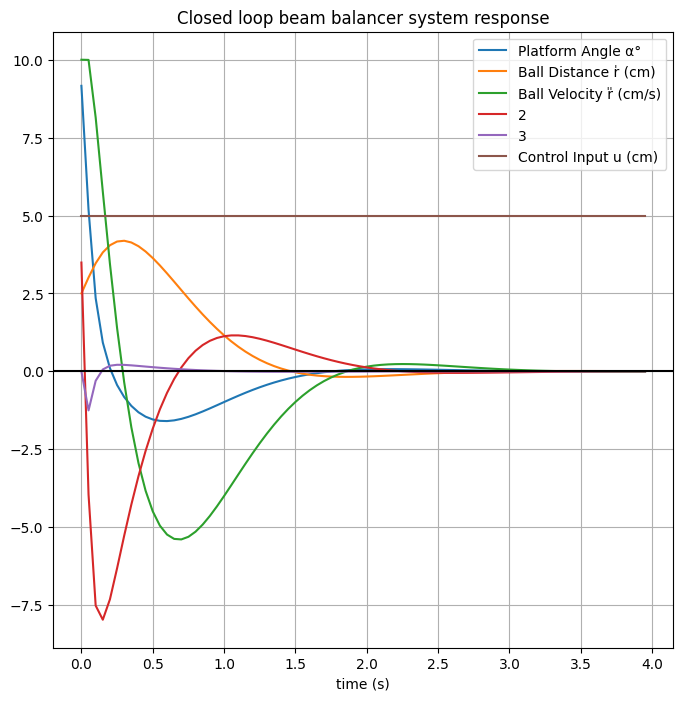

In [19]:
T, yout, xout =  signal.lsim(sys_cl, u, t, x0)
fig, axes = plt.subplots(figsize=(8,8), dpi=100)
#axes.plot(T, xout.transpose()[2], label = "xout")
axes.plot(T, np.degrees(yout), label = f"Platform Angle α{ds}")
axes.plot(T, xout.T[0]*100, label = f"Ball Distance {rdot} (cm)")
axes.plot(T, xout.T[1]*100, label = f"Ball Velocity {rdot2} (cm/s)")
axes.plot(T, xout.T[2]*100, label = f"2")
axes.plot(T, xout.T[3], label = f"3")


axes.plot(T, u*100, label = f"Control Input u (cm)")
axes.set_xlabel("time (s)")
axes.set_title("Closed loop beam balancer system response")
axes.axhline(0,color='black')
axes.grid()
axes.legend()
None

In [20]:
Nbar = rscale(A, B, C, D, K)
Nbar
nsys_cl = signal.StateSpace(A-B*K, B*Nbar, C, D)
nsys_cl

s: 4
z: [0.00 0.00 0.00 0.00 1.00]
tot: [[0.00 1.00 0.00 0.00 0.00]
 [0.00 0.00 6.03 0.00 0.00]
 [0.00 0.00 0.00 1.00 0.00]
 [0.00 0.00 0.00 0.00 1.00]
 [1.00 1.00 1.00 0.00 0.00]]
N:  [1.00 0.00 0.00 0.00 0.00]
Nx [1.00 0.00 0.00 0.00]
Nu: 0.0
Nbar [[2123.07]]


StateSpaceContinuous(
matrix([[0.00, 1.00, 0.00, 0.00],
        [0.00, 0.00, 6.03, 0.00],
        [0.00, 0.00, 0.00, 1.00],
        [-2123.07, -1194.23, -2008.00, -104.00]]),
matrix([[0.00],
        [0.00],
        [0.00],
        [2123.07]]),
array([[1, 1, 1, 0]]),
array([[0]]),
dt: None
)

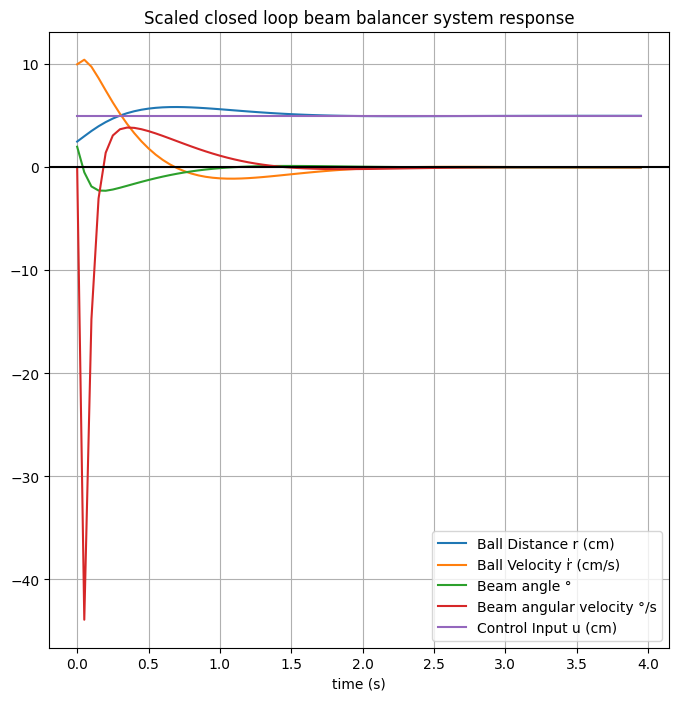

In [21]:
T, yout, xout =  signal.lsim(nsys_cl, u, t, x0)
fig, axes = plt.subplots(figsize=(8,8), dpi=100)
#axes.plot(T, np.degrees(yout), label = f"Platform Angle α{ds}")
axes.plot(T, xout.T[0]*100, label = f"Ball Distance r (cm)")
axes.plot(T, xout.T[1]*100, label = f"Ball Velocity {rdot} (cm/s)")
axes.plot(T, np.degrees(xout.T[2]), label = f"Beam angle {ds}")
axes.plot(T, np.degrees(xout.T[3]), label = f"Beam angular velocity {ds}/s")
axes.plot(T, u*100, label = f"Control Input u (cm)")
axes.set_xlabel("time (s)")
axes.set_title("Scaled closed loop beam balancer system response")
axes.axhline(0,color='black')
axes.grid()
axes.legend()
None

QgridWidget(grid_options={'fullWidthRows': True, 'syncColumnCellResize': True, 'forceFitColumns': False, 'defa…

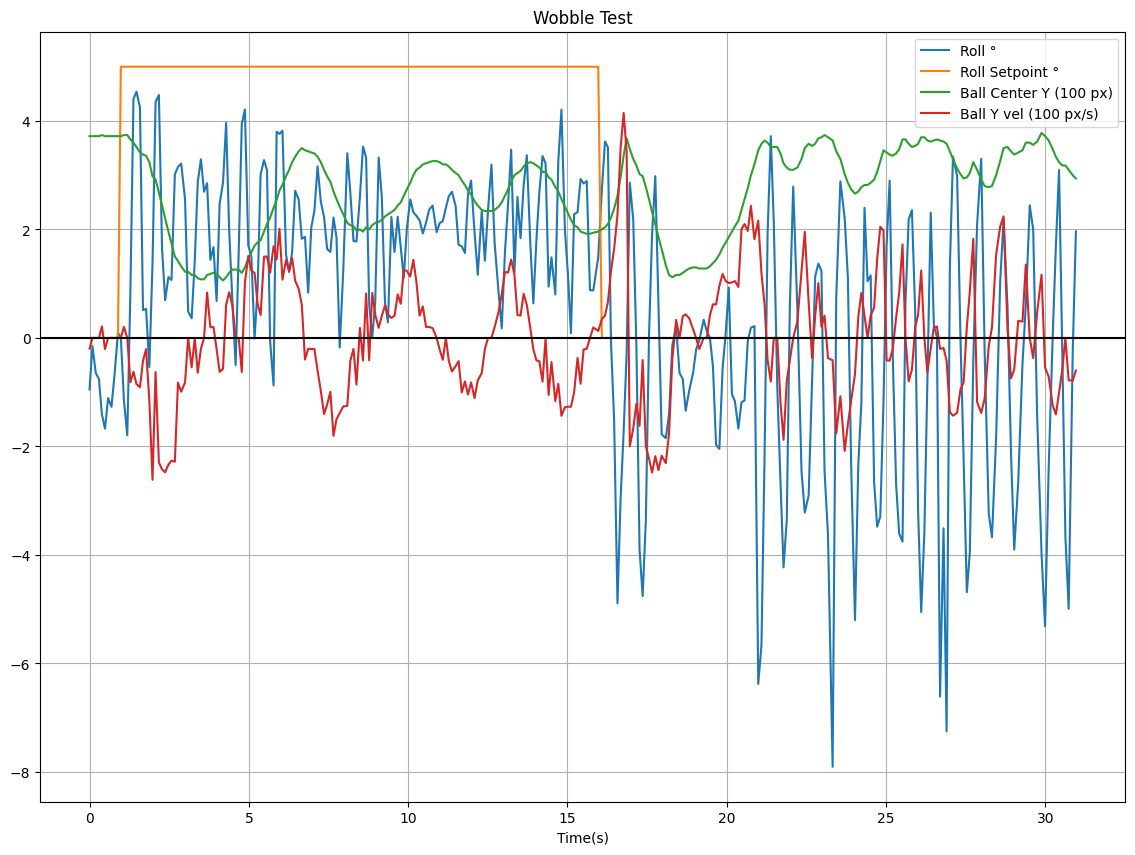

In [22]:
class WobbleTG(TableGrapher):
    def __init__(self, filename):
        super().__init__(filename)
        #super().__init__(filename, aoi_slice = slice(0, 40)) 


    def draw(self):
        self.title = "Wobble Test"
        roll = self.asnum('roll') 
        #pitch = self.asnum('pitch') 
        #cx = self.asnum('c3x')/100 
        cy = self.asnum('c3y')/100 
        #vx = self.asnum('v2x')/100 
        vy = self.asnum('v2y')/100 
        #pitch_setpoint = self.asnum('pitch_setpoint')
        roll_setpoint = self.asnum('roll_setpoint')


        self.axis.plot(self.time, roll, label=f"Roll {self.ds}")
        
        #self.axis.plot(self.time, pitch, label=f"Pitch {self.ds}")
        self.axis.plot(self.time, roll_setpoint, label=f"Roll Setpoint {self.ds}")
        #self.axis.plot(self.time, pitch_setpoint, label=f"Pitch Setpoint {self.ds}")
        #self.axis.plot(self.time, cx, label='Ball Center X (100 px)')
        self.axis.plot(self.time, cy, label='Ball Center Y (100 px)')
        #self.axis.plot(self.time, vx, label='Ball X vel (100 px/s)')
        self.axis.plot(self.time, vy, label='Ball Y vel (100 px/s)')        
        #self.axis.plot(cy, cx, label='Ball Path (px)')


        
wobbletg = WobbleTG("Pose_est-2024-07-31T16:44:26.547183.csv")
wobbletg.plot()

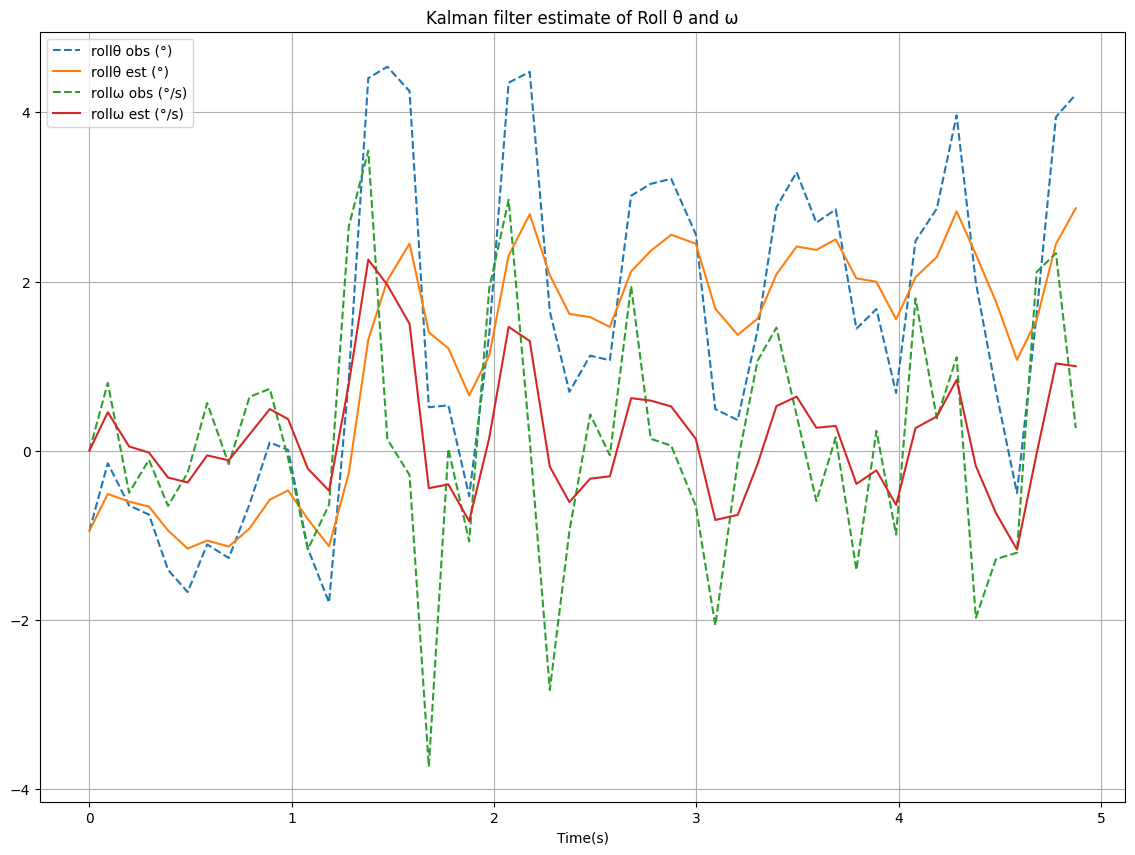

In [23]:
#aoi = slice(0, len(wobbletg.df))
aoi = slice(0, 50)
tim = wobbletg.asnum('time')[aoi]
dt = wobbletg.asnum('dt2')[aoi]
rollθ = wobbletg.asnum('roll')[aoi]
rollω = np.concatenate([[0], np.diff(rollθ)])




# Define time step
#dt = 0.1

# Initialize the filter with an initial estimate of the state matrix and the associated uncertainty (covariance)
x_estimated = np.array([[rollθ[0]], [0], [rollω[0]], [0]])
P_estimated = np.eye(4)


# Define the control input matrix as 0
B = np.array([[0], [0], [0], [0]])

# Define the control input as 0
u = np.array([[0], [0], [0], [0]])

# Define the measurement matrix
H = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])

# Define the measurement noise
R = np.array([[0.1, 0], [0, 0.1]])

# Define the process noise
Q = np.array([
        [0.01, 0.01, 0.01, 0.01], 
        [0.01, 0.02, 0.01, 0.01], 
        [0.01, 0.01, 0.03, 0.01], 
        [0.01, 0.01, 0.01, 0.04]])

xp = []
xmp = []
yp = []
ymp = []
xv = []
yv = []
for i in range(len(dt)): # 941, maybe
#for i in range(100):
    # Generate a measurement with some random noise
    #measurement = np.array([[i + np.random.normal(0, 0.1)], [i + np.random.normal(0, 0.1)]])
    #measurement = np.array([[np.cos(m.radians(i)) + np.random.normal(0, 0.1)], [np.sin(m.radians(i)) + np.random.normal(0, 0.1)]])
    measurement = np.array([[rollθ[i]],[rollω[i]]])

    # Define the state transition matrix
    A = np.array([[1, dt[i], 0, 0], [0, 1, 0, 0], [0, 0, 1, dt[i]], [0, 0, 0, 1]])




    # Prediction step
    x_predicted = np.dot(A, x_estimated)# + np.dot(B, u)
    P_predicted = np.dot(A, np.dot(P_estimated, A.T)) + Q

    # Correction step
    K = np.dot(P_predicted, np.dot(H.T, np.linalg.inv(np.dot(H, np.dot(P_predicted, H.T)) + R)))
    x_estimated = x_predicted + np.dot(K, (measurement - np.dot(H, x_predicted)))
    P_estimated = np.dot((np.eye(4) - np.dot(K, H)), P_predicted)

    xmp.append(measurement[0])
    ymp.append(measurement[1])

    # Print the estimated position and velocity
    #print("Estimated x_position: ", x_estimated[0][0])
    xp.append(x_estimated[0][0])
    #print("Estimated y_position: ", x_estimated[1][0])
    yp.append(x_estimated[1][0])
    #print("Estimated x_velocity: ", x_estimated[2][0])
    xv.append(x_estimated[2][0])
    #print("Estimated y_velocity: ", x_estimated[3][0])
    yv.append(x_estimated[3][0])
    
    
fig, ax = plt.subplots(figsize=(14, 10))
#ax.set_aspect('equal')

#tim = np.array(range(len(xp)))*dt

#ax.plot(xmp, ymp, label = "measured")
#ax.plot(xp, yp, label = "predicted")
xmp = np.array(xmp).reshape((np.array(xmp).shape[0],))
ymp = np.array(ymp).reshape((np.array(ymp).shape[0],))

ax.plot(tim, xmp, '--', label=f'rollθ obs ({wobbletg.ds})')
ax.plot(tim, xp, '', label=f'rollθ est ({wobbletg.ds})')
ax.plot(tim, ymp, '--', label=f'rollω obs ({wobbletg.ds}/s)')
ax.plot(tim, yp, '',label=f'rollω est ({wobbletg.ds}/s)')

#ax.set_xticks(np.arange(0, 70, 5))
#ax.set_yticks(np.arange(-1.5, 1.5, .5))

ax.grid()
ax.set_title("Kalman filter estimate of Roll θ and ω")
ax.set_xlabel("Time(s)")
ax.legend()

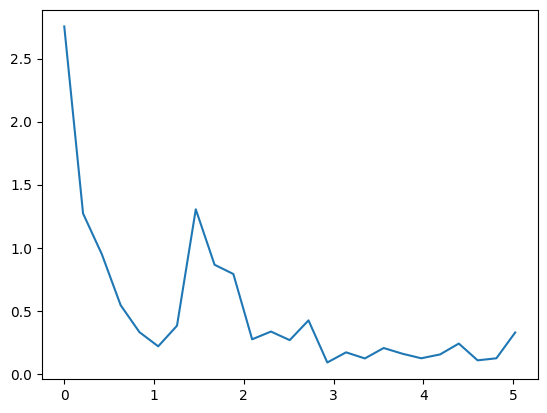

In [24]:
N = len(rollθ)
T = np.mean(dt)
yf = scipy.fftpack.fft(rollθ)
xf = np.linspace(0.0, 1.0/(2.0*T), N//2)
fig, ax = plt.subplots()
ax.plot(xf, 2.0/N * np.abs(yf[:N//2]))
len(yf), len(rollθ), N, T



In [25]:
#from scipy import zeros, signal, random
#https://stackoverflow.com/questions/40483518/how-to-real-time-filter-with-scipy-and-lfilter

def filter_sbs():
    data = random.random(2000)
    b = signal.firwin(150, 0.004)
    z = signal.lfilter_zi(b, 1) * data[0]
    result = np.zeros(data.size)
    for i, x in enumerate(data):
        result[i], z = signal.lfilter(b, 1, [x], zi=z)
    return result

#if __name__ == '__main__':
#    result = filter_sbs()

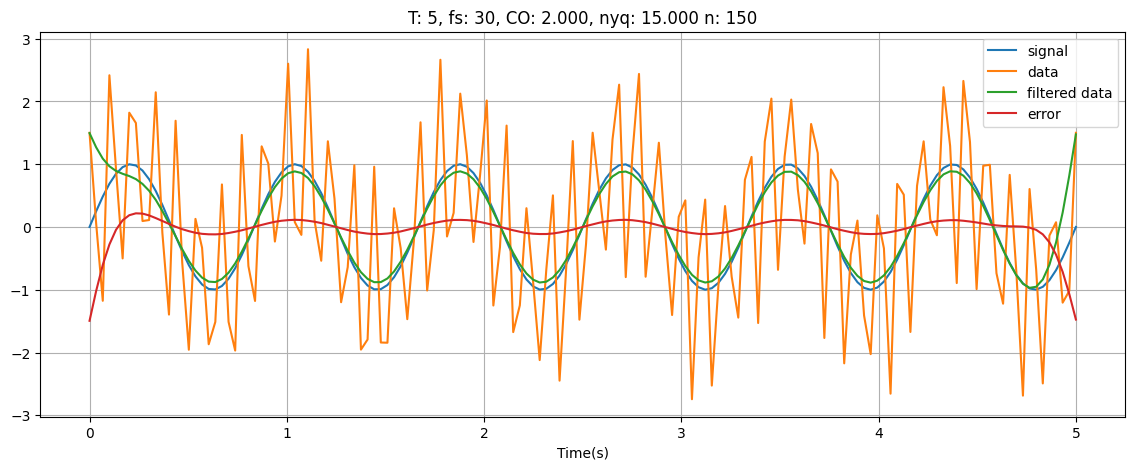

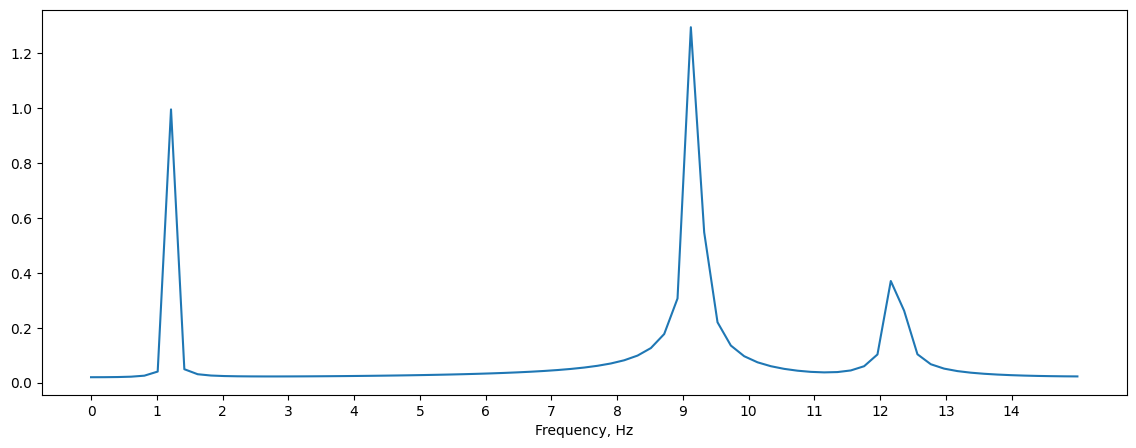

In [26]:
from scipy.signal import butter,filtfilt

def butter_lowpass_filter(data, cutoff, fs, order, nyq):
    # this works nicely
    normal_cutoff = cutoff / nyq
    # Get the filter coefficients 
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

def butter_lowpass_filter2(data, cutoff, fs, order, nyq):
    # this doesn't work so good
    normal_cutoff = cutoff / nyq
    # Get the filter coefficients 
    #b, a = butter(order, normal_cutoff, btype='low', analog=False)
    b = signal.firwin(150, 0.004)
    z = signal.lfilter_zi(b, 1) * data[0]
    result = np.zeros(data.size)
    for i, x in enumerate(data):
        result[i], z = signal.lfilter(b, 1, [x], zi=z)
    return result
    #y = filtfilt(b, a, data)
    #return y

def funt():
    # Filter requirements.
    T = 5.0         # Sample Period
    fs = 30.0       # sample rate, Hz
    cutoff = 2      # desired cutoff frequency of the filter, Hz ,      slightly higher than actual 1.2 Hz
    nyq = 0.5 * fs  # Nyquist Frequency
    order = 2       # sin wave can be approx represented as quadratic
    n = int(T * fs) # total number of samples
    t = np.linspace(0, T, n)
    
    # sin wave
    sig = np.sin(1.2*2*np.pi*t)
    # Lets add some noise
    noise = 1.5*np.cos(9*2*np.pi*t) + 0.5*np.sin(12.0*2*np.pi*t)
    data = sig + noise
    
    # Filter the data, and plot both the original and filtered signals.
    y = butter_lowpass_filter(data, cutoff, fs, order, nyq)
    
    error = sig - y
    
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(t, sig, '',label=f'signal')
    #ax.plot(t, noise, '--',label=f'noise')
    ax.plot(t, data, '',label=f'data')
    ax.plot(t, y, '',label=f'filtered data')
    ax.plot(t, error, '',label=f"error")

    #ax.set_xticks(np.arange(0, 70, 5))
    #ax.set_yticks(np.arange(-1.5, 1.5, .5))

    ax.grid()
    ax.set_title(f"T: {int(T)}, fs: {int(fs)}, CO: {cutoff:0.3f}, nyq: {nyq:0.3f} n: {n}")
    ax.set_xlabel("Time(s)")
    ax.legend()
    #display(fig)
    
    #N = len(rollθ)
    #T = np.mean(dt)
    TT = 1/fs
    yf = scipy.fftpack.fft(data)
    xf = np.linspace(0.0, 1.0/(2.0*TT), n//2)
    fig, ax = plt.subplots(figsize=(14,5))
    ax.plot(xf, 2.0/n * np.abs(yf[:n//2]))
    ax.set_xticks(np.arange(0, nyq, 1))


    #display(fig)
    ax.set_xlabel("Frequency, Hz")
    #len(yf), len(rollθ), N, T
funt() 

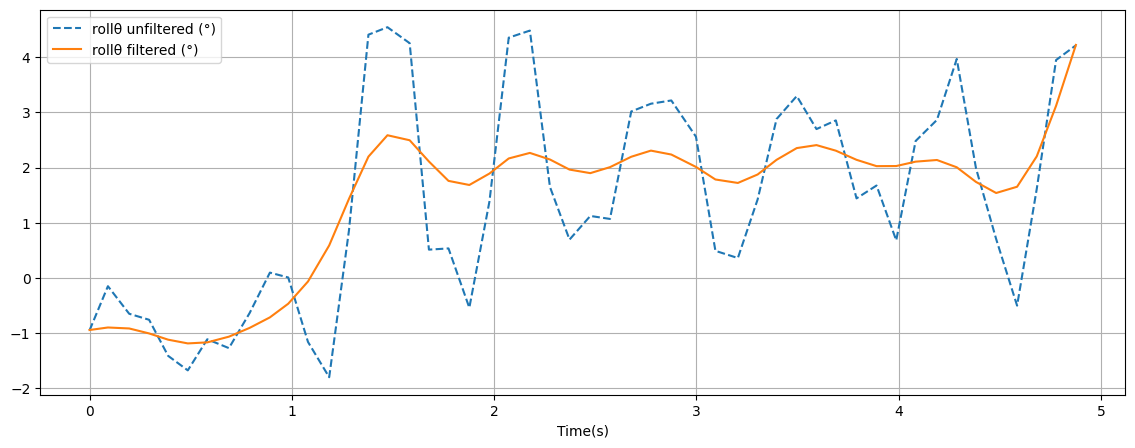

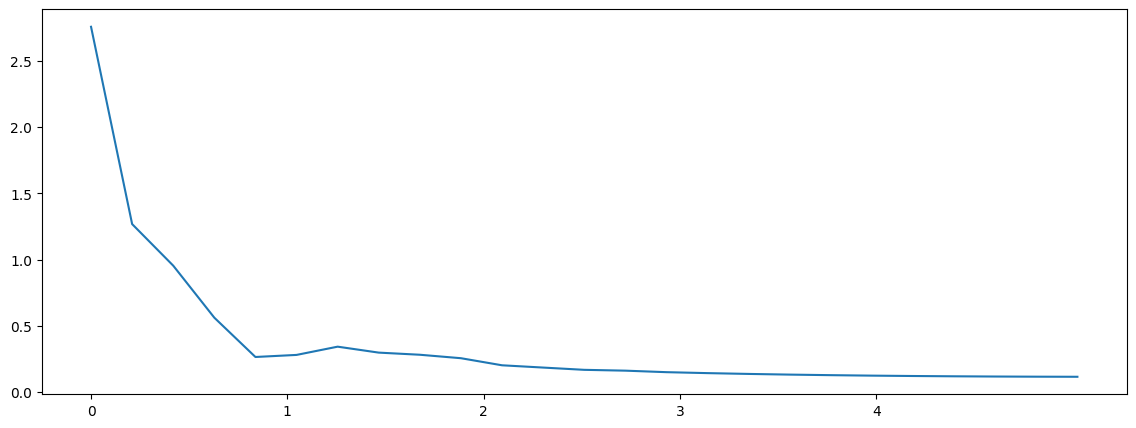

In [27]:
fs=1/np.mean(dt)
nyq = 5
frθ = butter_lowpass_filter(rollθ, cutoff=1, fs=fs, order=2, nyq=nyq)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tim, rollθ, '--', label=f'rollθ unfiltered ({wobbletg.ds})')
ax.plot(tim, frθ, '', label=f'rollθ filtered ({wobbletg.ds})')

ax.grid()
#ax.set_title(f"T: {int(T)}, fs: {int(fs)}, CO: {cutoff:0.3f}, nyq: {nyq:0.3f} n: {n}")
ax.set_xlabel("Time(s)")
ax.legend()

N = len(rollθ)

TT = 1/fs
yf = scipy.fftpack.fft(frθ)
xf = np.linspace(0.0, 1.0/(2.0*TT), N//2)
fig, ax = plt.subplots(figsize=(14,5))
ax.plot(xf, 2.0/N * np.abs(yf[:N//2]))
ax.set_xticks(np.arange(0, nyq, 1))
#ax.legend()
None